<a href="https://colab.research.google.com/github/AyatM711/CodVeda-_Intership/blob/main/Level_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---------------------------------------
###Task One : Regression Analysis
###1.Loading data and prepration
---------------------------------------
After Editing the CSV file in Excel and adding headers to the coloumns and seperate the values
the header coloumns and what each represent :
| Column    | Meaning                             |
| --------- | ----------------------------------- |
| CRIM      | Per-capita crime rate               |
| ZN        | Proportion of residential land      |
| INDUS     | Non-retail business land proportion |
| CHAS      | Charles River dummy variable        |
| NOX       | Nitric oxide concentration          |
| RM        | Average number of rooms             |
| AGE       | Proportion of older buildings       |
| DIS       | Distance to employment centres      |
| RAD       | Accessibility to radial highways    |
| TAX       | Property-tax rate                   |
| PTRATIO   | Pupil-teacher ratio                 |
| B         | Population-related index            |
| LSTAT     | Lower-status population percentage  |
| MEDV      | Median house value                  |




In [1]:
#Import the important libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("/content/house Prediction Data Set.csv")
print("Dataset shape:", df.shape)
print(df.head())

# Check for missing values (a regression model can't train on
# rows where the target MEDV is missing, so we drop them)
print("\nMissing values per column:")
print(df.isnull().sum())

missing_target = df["MEDV"].isnull().sum()
if missing_target > 0:
    print(f"\nDropping {missing_target} rows with missing MEDV (target) values.")
    df = df.dropna(subset=["MEDV"]).reset_index(drop=True)
    print("New dataset shape:", df.shape)


Dataset shape: (506, 14)
      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD    TAX  \
0  0.00632  18.0   2.31   0.0  0.538  6.575  65.2  4.0900    1  296.0   
1  0.02731   0.0   7.07   0.0  0.469  6.421  78.9  4.9671    2  242.0   
2  0.02729   0.0   7.07   0.0  0.469  7.185  61.1  4.9671    2  242.0   
3  0.03237   0.0   2.18   0.0  0.458  6.998  45.8  6.0622    3  222.0   
4  0.06905   0.0   2.18   0.0  0.458  7.147  54.2  6.0622    3  222.0   

   PTRATIO       B  LSTAT  MEDV  
0     15.3  396.90   4.98  24.0  
1     17.8  396.90   9.14  21.6  
2     17.8  392.83   4.03  34.7  
3     18.7  394.63   2.94  33.4  
4     18.7  396.90   5.33  36.2  

Missing values per column:
CRIM        0
ZN          0
INDUS       0
CHAS        0
NOX         0
RM          0
AGE         0
DIS         0
RAD         0
TAX         0
PTRATIO     0
B           0
LSTAT       0
MEDV       54
dtype: int64

Dropping 54 rows with missing MEDV (target) values.
New dataset shape: (452, 14)


# 2. Choose feature(s) and target
#   RM (avg rooms per dwelling) has the strongest linear
#   relationship with MEDV (house price) among the features.

In [9]:
X = df[["RM"]]          # feature (2D)
y = df["MEDV"]           # target

3. Split into training and testing sets

In [3]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print(f"\nTrain size: {X_train.shape[0]}  |  Test size: {X_test.shape[0]}")



Train size: 361  |  Test size: 91


4. Fit a linear regression model and Interpretation of  coefficients

In [4]:
model = LinearRegression()
model.fit(X_train, y_train)

print("\n--- Model Coefficients ---")
print(f"Intercept: {model.intercept_:.3f}")
print(f"Coefficient (RM): {model.coef_[0]:.3f}")
print(f"Interpretation: For every extra room (RM), the predicted median "
      f"house price changes by ${model.coef_[0]*1000:.2f}, holding all else constant.")


--- Model Coefficients ---
Intercept: -36.853
Coefficient (RM): 9.566
Interpretation: For every extra room (RM), the predicted median house price changes by $9565.93, holding all else constant.


 6. Visualize: Actual vs Predicted + Regression **Line**


Saved plot: task1_regression_results.png


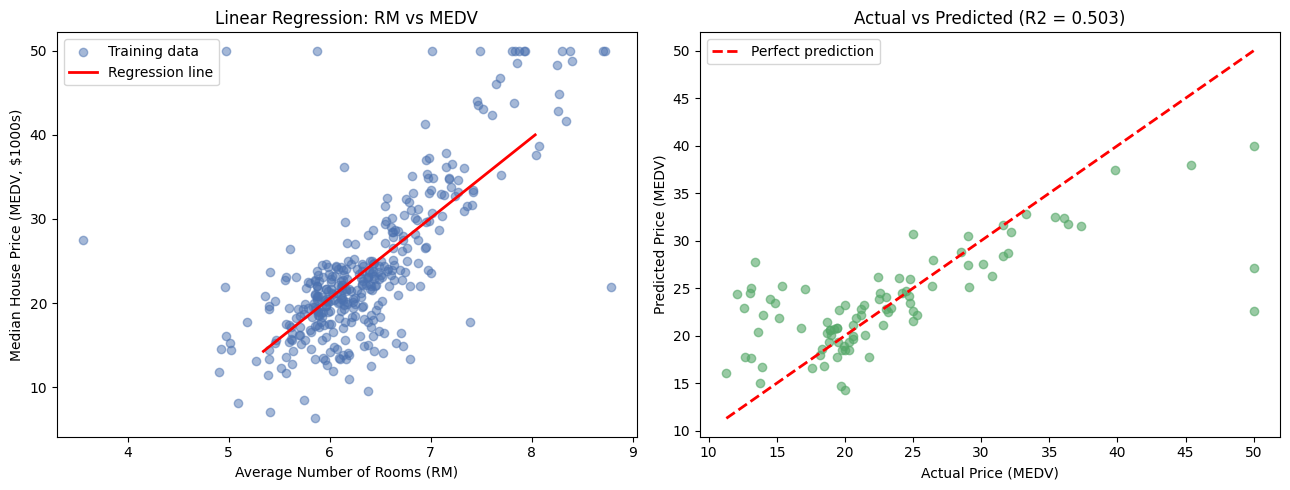

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score, mean_squared_error
import numpy as np

# Make predictions on the test set
y_pred = model.predict(X_test)

# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Regression line over scatter of training data
axes[0].scatter(X_train, y_train, alpha=0.5, color="#4C72B0", label="Training data")
# To plot the regression line, ensure X_test values are sorted to get a smooth line
# Also, ensure that if X_test is a DataFrame, it's passed correctly for prediction
# For single feature, we can just use the X_train range for the line if we want to show the model's overall fit
# Or, use sorted X_test as done previously.
# Let's keep it consistent with the original intent for the regression line on the first plot.
axes[0].plot(X_test.sort_values("RM"), model.predict(X_test.sort_values("RM")),
             color="red", linewidth=2, label="Regression line")
axes[0].set_xlabel("Average Number of Rooms (RM)")
axes[0].set_ylabel("Median House Price (MEDV, $1000s)")
axes[0].set_title("Linear Regression: RM vs MEDV")
axes[0].legend()

# Actual vs predicted scatter
axes[1].scatter(y_test, y_pred, alpha=0.6, color="#55A868")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
             color="red", linestyle="--", linewidth=2, label="Perfect prediction")
axes[1].set_xlabel("Actual Price (MEDV)")
axes[1].set_ylabel("Predicted Price (MEDV)")
axes[1].set_title(f"Actual vs Predicted (R2 = {r2:.3f})")
axes[1].legend()

plt.tight_layout()
plt.savefig("task1_regression_results.png", dpi=150)
print("\nSaved plot: task1_regression_results.png")